In [1]:
import re
import pandas as pd
from pathlib import Path
from itertools import combinations
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx
import numpy as np
import random
import math
import itertools
from collections import defaultdict
from typing import Iterable



/Users/bercaakbayir/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
from src.helper import kaggle_data_handler, print_results, generate_association_rules
from src.algorithms import (triangular_matrix_method, triples_method, 
                            apriori, multihash_algorithm, son_algorithm)

In [3]:
kaggle_link = 'https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows'

In [4]:
df = kaggle_data_handler(kaggle_link)

In [5]:
df.describe()

,IMDB_Rating,Meta_score,No_of_Votes
count,1000.000000,843.000000,1.000000e+03
mean,7.949300,77.971530,2.736929e+05
std,0.275491,12.376099,3.273727e+05
min,7.600000,28.000000,2.508800e+04
25%,7.700000,70.000000,5.552625e+04
50%,7.900000,79.000000,1.385485e+05
75%,8.100000,87.000000,3.741612e+05
max,9.300000,100.000000,2.343110e+06


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [7]:
df.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

# Defining the Baskets & Items

In [8]:
baskets = df[["Star1","Star2","Star3","Star4"]].values.tolist()
baskets = [set(row) for row in baskets]

In [9]:
baskets

[{'Bob Gunton', 'Morgan Freeman', 'Tim Robbins', 'William Sadler'},
 {'Al Pacino', 'Diane Keaton', 'James Caan', 'Marlon Brando'},
 {'Aaron Eckhart', 'Christian Bale', 'Heath Ledger', 'Michael Caine'},
 {'Al Pacino', 'Diane Keaton', 'Robert De Niro', 'Robert Duvall'},
 {'Henry Fonda', 'John Fiedler', 'Lee J. Cobb', 'Martin Balsam'},
 {'Elijah Wood', 'Ian McKellen', 'Orlando Bloom', 'Viggo Mortensen'},
 {'Bruce Willis', 'John Travolta', 'Samuel L. Jackson', 'Uma Thurman'},
 {'Ben Kingsley', 'Caroline Goodall', 'Liam Neeson', 'Ralph Fiennes'},
 {'Elliot Page', 'Joseph Gordon-Levitt', 'Ken Watanabe', 'Leonardo DiCaprio'},
 {'Brad Pitt', 'Edward Norton', 'Meat Loaf', 'Zach Grenier'},
 {'Elijah Wood', 'Ian McKellen', 'Orlando Bloom', 'Sean Bean'},
 {'Gary Sinise', 'Robin Wright', 'Sally Field', 'Tom Hanks'},
 {'Aldo Giuffrè', 'Clint Eastwood', 'Eli Wallach', 'Lee Van Cleef'},
 {'Elijah Wood', 'Ian McKellen', 'Orlando Bloom', 'Viggo Mortensen'},
 {'Carrie-Anne Moss', 'Keanu Reeves', 'Laurenc

# Support Calculation for Singletons

In [10]:
singleton_support = defaultdict(int)

for basket in baskets:
    for item in basket:
        singleton_support[item] += 1

singleton_support = dict(sorted(singleton_support.items(), key=lambda x: x[1], reverse=True))

print("Singleton Support:")
for item, support in singleton_support.items():
    print(f"  {item}: {support}")

Singleton Support:
  Robert De Niro: 17
  Tom Hanks: 14
  Al Pacino: 13
  Brad Pitt: 12
  Clint Eastwood: 12
  Christian Bale: 11
  Leonardo DiCaprio: 11
  Matt Damon: 11
  James Stewart: 10
  Michael Caine: 9
  Scarlett Johansson: 9
  Humphrey Bogart: 9
  Ethan Hawke: 9
  Johnny Depp: 9
  Denzel Washington: 9
  Harrison Ford: 8
  Aamir Khan: 8
  Morgan Freeman: 7
  Ian McKellen: 7
  Bruce Willis: 7
  Edward Norton: 7
  Toshirô Mifune: 7
  Russell Crowe: 7
  Robert Downey Jr.: 7
  Mark Ruffalo: 7
  Cary Grant: 7
  Jake Gyllenhaal: 7
  Emma Watson: 7
  Jeff Bridges: 7
  Tom Cruise: 7
  Diane Keaton: 6
  Samuel L. Jackson: 6
  Joe Pesci: 6
  Jack Nicholson: 6
  Matthew McConaughey: 6
  Tatsuya Nakadai: 6
  Gary Oldman: 6
  Charles Chaplin: 6
  Chris Evans: 6
  William Holden: 6
  Paul Newman: 6
  Shah Rukh Khan: 6
  Ed Harris: 6
  Christopher Plummer: 6
  Gene Hackman: 6
  Rachel McAdams: 6
  Daniel Radcliffe: 6
  Rupert Grint: 6
  Philip Seymour Hoffman: 6
  Josh Brolin: 6
  Julianne Mo

# Support Calculation for Doubletons

In [11]:
doubleton_support = defaultdict(int)

for basket in baskets:
    for pair in combinations(sorted(basket), 2):
        doubleton_support[pair] += 1

doubleton_support = dict(sorted(doubleton_support.items(), key=lambda x: x[1], reverse=True))

print("Doubleton Support:")
for pair, support in doubleton_support.items():
    print(f"  {pair}: {support}")

Doubleton Support:
  ('Daniel Radcliffe', 'Rupert Grint'): 6
  ('Daniel Radcliffe', 'Emma Watson'): 5
  ('Emma Watson', 'Rupert Grint'): 5
  ('Joe Pesci', 'Robert De Niro'): 4
  ('Tim Allen', 'Tom Hanks'): 4
  ('Al Pacino', 'Diane Keaton'): 3
  ('Christian Bale', 'Michael Caine'): 3
  ('Al Pacino', 'Robert De Niro'): 3
  ('Elijah Wood', 'Ian McKellen'): 3
  ('Elijah Wood', 'Orlando Bloom'): 3
  ('Ian McKellen', 'Orlando Bloom'): 3
  ('Carrie Fisher', 'Harrison Ford'): 3
  ('Carrie Fisher', 'Mark Hamill'): 3
  ('Harrison Ford', 'Mark Hamill'): 3
  ('Takashi Shimura', 'Toshirô Mifune'): 3
  ('Chris Evans', 'Joe Russo'): 3
  ('Chris Evans', 'Robert Downey Jr.'): 3
  ('Joe Russo', 'Robert Downey Jr.'): 3
  ('Mark Ruffalo', 'Robert Downey Jr.'): 3
  ('Tatsuya Nakadai', 'Toshirô Mifune'): 3
  ('Ethan Hawke', 'Julie Delpy'): 3
  ('Chris Evans', 'Scarlett Johansson'): 3
  ('Diane Keaton', 'Woody Allen'): 3
  ('Humphrey Bogart', 'Lauren Bacall'): 3
  ('Ethan Coen', 'John Turturro'): 3
  ('Elija

# Confidence 

In [12]:
def confidence(lhs, rhs, baskets, verbose=True):
    lhs = set(lhs)
    rhs = set(rhs)
    union = lhs | rhs

    support_lhs   = sum(1 for b in baskets if lhs.issubset(b))
    support_union = sum(1 for b in baskets if union.issubset(b))

    if support_lhs == 0:
        return None

    conf = support_union / support_lhs

    if verbose:
        print(f"  support({lhs}) = {support_lhs}")
        print(f"  support({lhs | rhs}) = {support_union}")
        print(f"  confidence({lhs} → {rhs}) = {support_union}/{support_lhs} = {conf:.4f}")

    return conf

In [13]:
confidence({"Christian Bale"}, {"Robert De Niro"}, baskets)


  support({'Christian Bale'}) = 11
  support({'Christian Bale', 'Robert De Niro'}) = 0
  confidence({'Christian Bale'} → {'Robert De Niro'}) = 0/11 = 0.0000


0.0

Interpretation : Christian Bale appears in 11 different movies. But Robert De Niro does not appear in any movie that Christian Bale appeared. Therefore, Confidence score is 0/11 = 0

In [14]:
confidence({"Emma Watson"}, {"Rupert Grint"}, baskets)


  support({'Emma Watson'}) = 7
  support({'Emma Watson', 'Rupert Grint'}) = 5
  confidence({'Emma Watson'} → {'Rupert Grint'}) = 5/7 = 0.7143


0.7142857142857143

Interpretation : Emma Watson appears in 7 diferent movies. Rubert Grint appears in 5 movies among those 7 movies that Emma Watson appeared in. Therefore, confidence level is 5/7 = 0.71

In [15]:
confidence({"Orlando Bloom"}, {"Elijah Wood"}, baskets)


  support({'Orlando Bloom'}) = 4
  support({'Orlando Bloom', 'Elijah Wood'}) = 3
  confidence({'Orlando Bloom'} → {'Elijah Wood'}) = 3/4 = 0.7500


0.75

Interpretation : Orlando Bloom appears in 4 movies. Elija Wood appears in 3 movies among those 4 movies that Orlando Bloom appeared in.Therefore, confidence level is 3/4 = 0.75

# Interest

In [16]:
def interest(lhs, rhs, baskets):
    """
    lhs: list or set of items (left-hand side)
    rhs: list or set of items (right-hand side)
    """
    rhs = set(rhs)

    conf = confidence(lhs, rhs, baskets)

    if conf is None:
        return None

    support_rhs = sum(1 for b in baskets if rhs.issubset(b))
    prob_rhs = support_rhs / len(baskets)

    interest_score = conf - prob_rhs

    print(f"  P({rhs}) = {support_rhs}/{len(baskets)} = {prob_rhs:.4f}")
    print(f"  interest({set(lhs)} → {rhs}) = {conf:.4f} - {prob_rhs:.4f} = {interest_score:.4f}")
    return interest_score

In [17]:
interest({"Orlando Bloom"}, {"Elijah Wood"}, baskets)

  support({'Orlando Bloom'}) = 4
  support({'Orlando Bloom', 'Elijah Wood'}) = 3
  confidence({'Orlando Bloom'} → {'Elijah Wood'}) = 3/4 = 0.7500
  P({'Elijah Wood'}) = 3/1000 = 0.0030
  interest({'Orlando Bloom'} → {'Elijah Wood'}) = 0.7500 - 0.0030 = 0.7470


0.747

Confidence level is 0.75 for Orlando Bloom -> Elijah Wood.

Elija Wood appears in 3 movies among all 1000 movies in dataset -> 3/1000 = 0.003

Therefore, interest level is ;

0.75 - 0.003 = 0.747

So, presence of Orlando Bloom encourages Elijah Wood to be in that movie.

# Finding Association rules

In [18]:
def find_association_rules(baskets, singleton_support, top_support_pct, min_confidence_pct=50):
    """
    baskets: list of sets
    singleton_support: dict {item: support}
    top_support_pct: top n% of items by support (e.g. 20 for top 20%)
    min_confidence_pct: minimum confidence threshold in percentage (default=50)
    """
    min_confidence = min_confidence_pct / 100

    sorted_items = sorted(singleton_support.items(), key=lambda x: x[1], reverse=True)
    top_n = max(1, int(len(sorted_items) * top_support_pct / 100))
    frequent_singletons = {item for item, sup in sorted_items[:top_n]}

    rules = []

    for item in frequent_singletons:
        for other_item in frequent_singletons:
            if item == other_item:
                continue

            conf = confidence({item}, {other_item}, baskets, verbose=False)
            if conf is not None and conf >= min_confidence:
                rules.append({
                    "lhs": item,
                    "rhs": other_item,
                    "support": singleton_support[item],
                    "confidence": conf
                })

    rules = sorted(rules, key=lambda x: x["confidence"], reverse=True)

    print(f"Found {len(rules)} association rules | top {top_support_pct}% support ({top_n} items) | confidence >= {min_confidence_pct}%\n")
    for rule in rules:
        print(f"  {rule['lhs']} → {rule['rhs']}  |  support: {rule['support']}  |  confidence: {rule['confidence']*100:.2f}%")

    return rules

In [19]:
rules = find_association_rules(baskets, singleton_support, top_support_pct=1, min_confidence_pct=20)

Found 8 association rules | top 1% support (27 items) | confidence >= 20%

  Robert Downey Jr. → Mark Ruffalo  |  support: 7  |  confidence: 42.86%
  Mark Ruffalo → Robert Downey Jr.  |  support: 7  |  confidence: 42.86%
  Michael Caine → Christian Bale  |  support: 9  |  confidence: 33.33%
  Morgan Freeman → Clint Eastwood  |  support: 7  |  confidence: 28.57%
  Robert Downey Jr. → Scarlett Johansson  |  support: 7  |  confidence: 28.57%
  Christian Bale → Michael Caine  |  support: 11  |  confidence: 27.27%
  Al Pacino → Robert De Niro  |  support: 13  |  confidence: 23.08%
  Scarlett Johansson → Robert Downey Jr.  |  support: 9  |  confidence: 22.22%


# Pair Counting Data Structures

## The Triangular Matrix Method


When counting pair occurrences across baskets, a naive 2D array `a[i][j]` wastes half its space — both `a[i][j]` and `a[j][i]` would store the same pair `{i, j}`.

**Goal:** Store counts for all pairs $\{i, j\}$ where $i < j$, using a single flat 1D array with no wasted slots.


For $n$ items, only the **upper triangle** of the matrix is needed:

|       | j=1 | j=2     | j=3     | j=4     |
|-------|-----|---------|---------|---------|
| **i=1** | —   | {1, 2}  | {1, 3}  | {1, 4}  |
| **i=2** | —   | —       | {2, 3}  | {2, 4}  |
| **i=3** | —   | —       | —       | {3, 4}  |
| **i=4** | —   | —       | —       | —       |

These 6 pairs (for $n = 4$) are stored **in lexicographic order** in a 1D array `a[k]`:

| k    | 1      | 2      | 3      | 4      | 5      | 6      |
|------|--------|--------|--------|--------|--------|--------|
| pair | {1, 2} | {1, 3} | {1, 4} | {2, 3} | {2, 4} | {3, 4} |

---

Index Formula

To look up the count for pair $\{i, j\}$ (with $i < j$) directly:

$$k = (i - 1)\!\left(n - \frac{i}{2}\right) + j - i$$

---

Space Complexity

Total pairs stored $= \binom{n}{2} = \frac{n(n-1)}{2}$

At 4 bytes per integer, total memory required:

$$\text{Memory} = 2n^2 \text{ bytes} \approx \frac{n^2}{2} \times 4 \text{ bytes}$$

**Example:** With $n = 32{,}000$ items and 2 GB of RAM:
- We need $2n^2$ bytes $\leq 2^{31}$ bytes
- This gives $n \leq 2^{15} \approx 32{,}768$ items maximum

## Triples Method

The triangular matrix allocates space for **every possible pair** upfront — even pairs that never appear in any basket. When the data is sparse (most pairs have count 0), this wastes enormous memory.

**Goal:** Store only the pairs that actually appear, skipping all zero-count pairs entirely.


**Key Idea:** Explicit (i, j, count) Records

Instead of a pre-allocated array, each observed pair is stored as a **triple**:

$$[i, \; j, \; c] \quad \text{where } i < j, \text{ and } c = \text{count of pair } \{i, j\}$$

A **hash table** keyed on $(i, j)$ provides fast lookup and insertion.

Example (n = 4, sparse baskets)

Suppose only 3 of the 6 possible pairs were ever seen:

| Triple | Meaning |
|--------|---------|
| `[1, 2, 7]` | pair {1, 2} appeared 7 times |
| `[1, 4, 3]` | pair {1, 4} appeared 3 times |
| `[2, 3, 12]` | pair {2, 3} appeared 12 times |

Pairs `{1,3}`, `{2,4}`, `{3,4}` → **not stored at all** (count = 0)

---

Hash Table Structure

The triples are stored in a hash table indexed by the pair $(i, j)$:

```
hash_table key=(i,j) → value=count

  (1, 2)  →  7
  (1, 4)  →  3
  (2, 3)  →  12
```

**Lookup:** To get the count for any pair $\{i, j\}$:
- Hash $(i, j)$ → bucket
- If found: return count
- If not found: count is **0** (pair never seen)

**Update:** When pair $\{i, j\}$ is seen in a basket:
- If key exists: increment count by 1
- If key absent: insert new triple $[i, j, 1]$

---

Space Complexity

Let $p$ = number of distinct pairs that actually appear in at least one basket.

| Component | Space |
|-----------|-------|
| Each triple $(i, j, c)$ | $3 \times 4 = 12$ bytes |
| Hash table overhead | $\approx$ constant factor |
| **Total** | $\approx 12p$ bytes |

Compare to the triangular matrix, which always uses:

$$2n^2 \text{ bytes regardless of how many pairs appear}$$

## Triple Matrix Method vs Triples Method


| Property | Triangular Matrix | Triples Method |
|----------|-----|-----|
| Space per pair | 1 integer | 3 integers |
| Stores zero-count pairs | Yes |  No |
| Total space | $O(n^2)$ always | $O(p)$ where $p$ = pairs seen |
| Lookup speed | Direct index — $O(1)$ | Hash table — $O(1)$ avg |
| Best when | $> \frac{1}{3}$ of pairs appear | $< \frac{1}{3}$ of pairs appear |
| Typical use case | Dense, small item sets | Sparse, large item sets |


In [20]:
tmm_counts = triangular_matrix_method(baskets)

In [21]:
triples_counts = triples_method(baskets)

In [22]:
tmm_counts

{('Aamir Bashir', 'Anupam Kher'): 1,
 ('Aamir Bashir', 'Jimmy Sheirgill'): 1,
 ('Aamir Bashir', 'Naseeruddin Shah'): 1,
 ('Aamir Khan', 'Akshaye Khanna'): 1,
 ('Aamir Khan', 'Amole Gupte'): 1,
 ('Aamir Khan', 'Anushka Sharma'): 1,
 ('Aamir Khan', 'Boman Irani'): 1,
 ('Aamir Khan', 'Darsheel Safary'): 1,
 ('Aamir Khan', 'Fatima Sana Shaikh'): 1,
 ('Aamir Khan', 'Gracy Singh'): 1,
 ('Aamir Khan', 'Karisma Kapoor'): 1,
 ('Aamir Khan', 'Madhavan'): 1,
 ('Aamir Khan', 'Mona Singh'): 1,
 ('Aamir Khan', 'Preity Zinta'): 1,
 ('Aamir Khan', 'Rachel Shelley'): 1,
 ('Aamir Khan', 'Raghuvir Yadav'): 1,
 ('Aamir Khan', 'Raveena Tandon'): 1,
 ('Aamir Khan', 'Saif Ali Khan'): 1,
 ('Aamir Khan', 'Sakshi Tanwar'): 1,
 ('Aamir Khan', 'Salman Khan'): 1,
 ('Aamir Khan', 'Sanjay Dutt'): 1,
 ('Aamir Khan', 'Sanya Malhotra'): 1,
 ('Aamir Khan', 'Sharman Joshi'): 2,
 ('Aamir Khan', 'Siddharth'): 1,
 ('Aamir Khan', 'Soha Ali Khan'): 1,
 ('Aamir Khan', 'Tisca Chopra'): 1,
 ('Aaron Eckhart', 'Christian Bale'): 1

In [23]:
triples_counts

{('Daniel Radcliffe', 'Rupert Grint'): 6,
 ('Daniel Radcliffe', 'Emma Watson'): 5,
 ('Emma Watson', 'Rupert Grint'): 5,
 ('Joe Pesci', 'Robert De Niro'): 4,
 ('Tim Allen', 'Tom Hanks'): 4,
 ('Al Pacino', 'Diane Keaton'): 3,
 ('Christian Bale', 'Michael Caine'): 3,
 ('Al Pacino', 'Robert De Niro'): 3,
 ('Elijah Wood', 'Ian McKellen'): 3,
 ('Elijah Wood', 'Orlando Bloom'): 3,
 ('Ian McKellen', 'Orlando Bloom'): 3,
 ('Carrie Fisher', 'Harrison Ford'): 3,
 ('Carrie Fisher', 'Mark Hamill'): 3,
 ('Harrison Ford', 'Mark Hamill'): 3,
 ('Takashi Shimura', 'Toshirô Mifune'): 3,
 ('Chris Evans', 'Joe Russo'): 3,
 ('Chris Evans', 'Robert Downey Jr.'): 3,
 ('Joe Russo', 'Robert Downey Jr.'): 3,
 ('Mark Ruffalo', 'Robert Downey Jr.'): 3,
 ('Tatsuya Nakadai', 'Toshirô Mifune'): 3,
 ('Ethan Hawke', 'Julie Delpy'): 3,
 ('Chris Evans', 'Scarlett Johansson'): 3,
 ('Diane Keaton', 'Woody Allen'): 3,
 ('Humphrey Bogart', 'Lauren Bacall'): 3,
 ('Ethan Coen', 'John Turturro'): 3,
 ('Elijah Wood', 'Viggo Mort

# A-Priori Algorithm

In [24]:
apriori_results = apriori(baskets, support_threshold=3)

Pass 1 : Calculation occureness of items
Occureness of Items: {'Tim Robbins': 4, 'Morgan Freeman': 7, 'Bob Gunton': 1, 'William Sadler': 1, 'Marlon Brando': 4, 'James Caan': 3, 'Diane Keaton': 6, 'Al Pacino': 13, 'Heath Ledger': 2, 'Michael Caine': 9, 'Christian Bale': 11, 'Aaron Eckhart': 1, 'Robert Duvall': 4, 'Robert De Niro': 17, 'Martin Balsam': 3, 'John Fiedler': 2, 'Lee J. Cobb': 3, 'Henry Fonda': 4, 'Ian McKellen': 7, 'Orlando Bloom': 4, 'Elijah Wood': 3, 'Viggo Mortensen': 5, 'Samuel L. Jackson': 6, 'Bruce Willis': 7, 'Uma Thurman': 4, 'John Travolta': 1, 'Caroline Goodall': 1, 'Liam Neeson': 4, 'Ben Kingsley': 4, 'Ralph Fiennes': 3, 'Elliot Page': 1, 'Leonardo DiCaprio': 11, 'Joseph Gordon-Levitt': 4, 'Ken Watanabe': 4, 'Zach Grenier': 1, 'Brad Pitt': 12, 'Edward Norton': 7, 'Meat Loaf': 1, 'Sean Bean': 1, 'Tom Hanks': 14, 'Robin Wright': 3, 'Gary Sinise': 2, 'Sally Field': 1, 'Lee Van Cleef': 2, 'Aldo Giuffrè': 1, 'Clint Eastwood': 12, 'Eli Wallach': 2, 'Lilly Wachowski': 1,

In [25]:
df_apriori = generate_association_rules(apriori_results)

In [26]:
df_apriori[df_apriori["confidence"] >= 50]

,antecedents,consequents,support,confidence
0,"{Emma Watson, Rupert Grint}",{Daniel Radcliffe},5,100.00
1,{Daniel Radcliffe},{Rupert Grint},6,100.00
2,"{Ian McKellen, Elijah Wood}",{Orlando Bloom},3,100.00
3,"{Orlando Bloom, Ian McKellen}",{Elijah Wood},3,100.00
4,{Tim Allen},{Tom Hanks},4,100.00
5,{Elijah Wood},{Orlando Bloom},3,100.00
6,"{Mark Hamill, Harrison Ford}",{Carrie Fisher},3,100.00
7,{Elijah Wood},{Ian McKellen},3,100.00
8,"{Emma Watson, Daniel Radcliffe}",{Rupert Grint},5,100.00
9,{Mark Hamill},{Carrie Fisher},3,100.00


# The Multihash Algorithm

In [28]:
result_mh = multihash_algorithm(baskets, support=2)

from collections import defaultdict
by_size = defaultdict(list)
for itemset, count in result_mh.items():
    by_size[len(itemset)].append((itemset, count))

for size in sorted(by_size):
    label = {1: "Singletons", 2: "Pairs", 3: "Triples"}.get(size, f"Size-{size}")
    print(f"\n{label}:")
    for itemset, count in sorted(by_size[size], key=lambda x: -x[1]):
        items_str = str(set(itemset))
        print(f"  {items_str:<40}  support = {count}")


Singletons:
  {'Robert De Niro'}                        support = 17
  {'Tom Hanks'}                             support = 14
  {'Al Pacino'}                             support = 13
  {'Clint Eastwood'}                        support = 12
  {'Brad Pitt'}                             support = 12
  {'Matt Damon'}                            support = 11
  {'Christian Bale'}                        support = 11
  {'Leonardo DiCaprio'}                     support = 11
  {'James Stewart'}                         support = 10
  {'Humphrey Bogart'}                       support = 9
  {'Johnny Depp'}                           support = 9
  {'Scarlett Johansson'}                    support = 9
  {'Ethan Hawke'}                           support = 9
  {'Denzel Washington'}                     support = 9
  {'Michael Caine'}                         support = 9
  {'Harrison Ford'}                         support = 8
  {'Aamir Khan'}                            support = 8
  {'Toshirô Mifune'}      

In [ ]:
df_mh = generate_association_rules(result_mh)

In [ ]:
df_mh

# The SON Algorithm (Using Multihash)

In [29]:
result_son = son_algorithm(
        baskets,
        support_threshold=2,
        num_chunks=10,
        num_hash_tables=2,
    )
print_results(result_son)

Results
  Chunks used : 10
  Local support : 1
  Candidate itemsets : 13492
  False positives : 12701  (eliminated in pass 2)
  Truly frequent : 791

  Singletons (641 frequent):
    {Robert De Niro}  [support=17]
    {Tom Hanks}  [support=14]
    {Al Pacino}  [support=13]
    {Brad Pitt}  [support=12]
    {Clint Eastwood}  [support=12]
    {Matt Damon}  [support=11]
    {Christian Bale}  [support=11]
    {Leonardo DiCaprio}  [support=11]
    {James Stewart}  [support=10]
    {Humphrey Bogart}  [support=9]
    {Scarlett Johansson}  [support=9]
    {Denzel Washington}  [support=9]
    {Michael Caine}  [support=9]
    {Johnny Depp}  [support=9]
    {Ethan Hawke}  [support=9]
    {Harrison Ford}  [support=8]
    {Aamir Khan}  [support=8]
    {Toshirô Mifune}  [support=7]
    {Jeff Bridges}  [support=7]
    {Russell Crowe}  [support=7]
    ... and 621 more

  Pairs (121 frequent):
    {Daniel Radcliffe, Rupert Grint}  [support=6]
    {Emma Watson, Rupert Grint}  [support=5]
    {Daniel Rad

In [30]:
df_son = generate_association_rules(result_son["frequent_itemsets"], result_son["global_counts"])

In [31]:
df_son

,antecedents,consequents,support,confidence
0,{Paulette Goddard},{Charles Chaplin},2,100.00
1,{Holly Hunter},{Craig T. Nelson},2,100.00
2,{Elijah Wood},{Ian McKellen},3,100.00
3,{Mark Hamill},{Harrison Ford},3,100.00
4,{Michael Gambon},{Rupert Grint},2,100.00
...,...,...,...,...
328,{Clint Eastwood},{Lee Van Cleef},2,16.67
329,{Clint Eastwood},{Morgan Freeman},2,16.67
330,{Clint Eastwood},{Gian Maria Volontè},2,16.67
331,{Tom Hanks},{Gary Sinise},2,14.29


# Algorithm Benchmark

In [37]:
def benchmark(
    baskets: list[set],
    support_range: range = range(2, 11),
) -> pd.DataFrame:

    algorithms = {
        "apriori":   lambda b, s: apriori(b, s),
        "multihash": lambda b, s: multihash_algorithm(b, s),
        "son":       lambda b, s: son_algorithm(b, s),
    }

    def extract_itemsets(result) -> set[frozenset]:
        if isinstance(result, dict) and "frequent_itemsets" in result:
            return result["frequent_itemsets"]
        return {k for k, v in result.items() if v > 0}

    records = []

    for support in support_range:

        # Run apriori first to get ground truth
        tracemalloc.start()
        t_start = time.perf_counter()
        apriori_result = apriori(baskets, support)
        t_end = time.perf_counter()
        _, apriori_peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        ground_truth = extract_itemsets(apriori_result)

        records.append({
            "algorithm":         "apriori",
            "support":           support,
            "runtime_s":         round(t_end - t_start, 4),
            "peak_memory_kb":    round(apriori_peak / 1024, 2),
            "frequent_itemsets": len(ground_truth),
            "precision":         1.0,
            "recall":            1.0,
        })

        for algo_name, algo_fn in [("multihash", algorithms["multihash"]),
                                    ("son",       algorithms["son"])]:

            tracemalloc.start()
            t_start = time.perf_counter()
            result = algo_fn(baskets, support)
            t_end = time.perf_counter()
            _, peak = tracemalloc.get_traced_memory()
            tracemalloc.stop()

            predicted = extract_itemsets(result)

            tp = len(predicted & ground_truth)
            fp = len(predicted - ground_truth)
            fn = len(ground_truth - predicted)

            precision = tp / (tp + fp) if (tp + fp) > 0 else 1.0
            recall    = tp / (tp + fn) if (tp + fn) > 0 else 1.0

            records.append({
                "algorithm":         algo_name,
                "support":           support,
                "runtime_s":         round(t_end - t_start, 4),
                "peak_memory_kb":    round(peak / 1024, 2),
                "frequent_itemsets": len(predicted),
                "precision":         round(precision, 4),
                "recall":            round(recall, 4),
            })

    df = pd.DataFrame(records)
    df = df.sort_values(["support", "algorithm"]).reset_index(drop=True)
    return df

In [38]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

def plot_benchmark(df: pd.DataFrame) -> None:
    algorithms = df["algorithm"].unique()

    colors = {
        "apriori":   "#378ADD",
        "multihash": "#1D9E75",
        "son":       "#D85A30",
    }
    markers = {
        "apriori":   "o",
        "multihash": "s",
        "son":       "^",
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor("#FAFAFA")

    metrics = [
        ("runtime_s",       "Runtime (seconds)",    axes[0], "Runtime by support threshold"),
        ("peak_memory_kb",  "Peak memory (KB)",     axes[1], "Memory usage by support threshold"),
    ]

    for col, ylabel, ax, title in metrics:
        ax.set_facecolor("#FAFAFA")

        for algo in algorithms:
            subset = df[df["algorithm"] == algo].sort_values("support")
            ax.plot(
                subset["support"],
                subset[col],
                label=algo,
                color=colors.get(algo, "#888"),
                marker=markers.get(algo, "o"),
                linewidth=2,
                markersize=6,
                markeredgewidth=1.5,
                markeredgecolor="white",
            )

        ax.set_title(title, fontsize=13, fontweight="500", pad=12, color="#2C2C2A")
        ax.set_xlabel("Support threshold", fontsize=11, color="#5F5E5A")
        ax.set_ylabel(ylabel, fontsize=11, color="#5F5E5A")

        ax.set_xticks(range(2, 11))
        ax.tick_params(colors="#888780", labelsize=10)
        for spine in ax.spines.values():
            spine.set_edgecolor("#D3D1C7")
            spine.set_linewidth(0.8)

        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.3g}"))
        ax.grid(axis="y", color="#D3D1C7", linewidth=0.6, linestyle="--", alpha=0.7)
        ax.grid(axis="x", color="#D3D1C7", linewidth=0.4, linestyle=":", alpha=0.5)
        ax.set_axisbelow(True)

        legend = ax.legend(
            frameon=True,
            framealpha=0.9,
            edgecolor="#D3D1C7",
            fontsize=10,
            loc="upper right",
        )
        legend.get_frame().set_linewidth(0.6)

    plt.tight_layout(pad=2.0)
    plt.savefig("benchmark.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

In [39]:
import warnings
warnings.filterwarnings("ignore")   # suppress apriori's print noise if desired

# optionally redirect stdout to suppress per-pass prints during benchmarking
import os, sys

class _Silent:
    def write(self, *a): pass
    def flush(self): pass

sys.stdout = _Silent()
df = benchmark(baskets)
sys.stdout = sys.__stdout__

print(df.to_string(index=False))

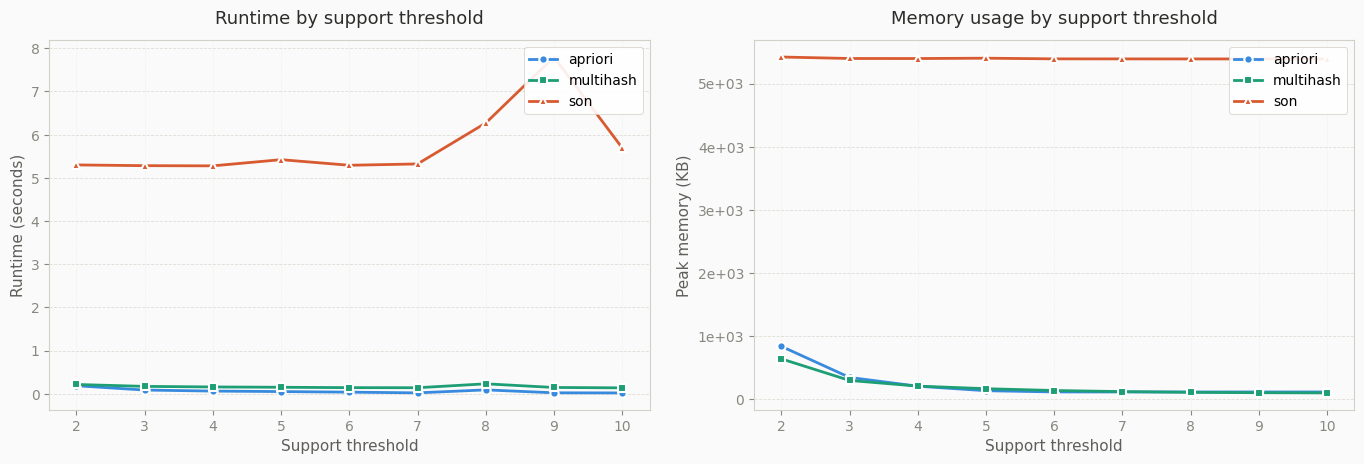

In [40]:
plot_benchmark(df)
